<a href="https://colab.research.google.com/github/AniruddhaChaudhury2006/FaceMaskDetection/blob/main/Face_Mask_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install kaggle

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d omkargurav/face-mask-dataset

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:01<00:00, 107MB/s]



In [3]:
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'
with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print("Dataset extracted")

Dataset extracted


In [4]:
!ls

data  face-mask-dataset.zip  sample_data


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [6]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_1925.jpg', 'with_mask_2797.jpg', 'with_mask_2716.jpg', 'with_mask_473.jpg', 'with_mask_1182.jpg']
['with_mask_2139.jpg', 'with_mask_3358.jpg', 'with_mask_2420.jpg', 'with_mask_2552.jpg', 'with_mask_611.jpg']


In [7]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_1022.jpg', 'without_mask_1092.jpg', 'without_mask_2136.jpg', 'without_mask_1426.jpg', 'without_mask_2959.jpg']
['without_mask_1155.jpg', 'without_mask_1074.jpg', 'without_mask_2965.jpg', 'without_mask_1444.jpg', 'without_mask_1468.jpg']


In [8]:
print('Number of with mask images: ', len(with_mask_files))
print('Number of without mask images: ', len(without_mask_files))

Number of with mask images:  3725
Number of without mask images:  3828


In [9]:
with_mask_labels = [1]*3725
without_mask_labels = [0]*3828
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [10]:
print(len(with_mask_labels))
print(len(without_mask_labels))


3725
3828


In [11]:
labels = with_mask_labels + without_mask_labels
print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


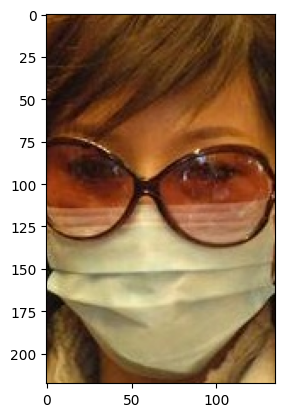

In [12]:
img = mpimg.imread('/content/data/with_mask/with_mask_10.jpg')
imgplot = plt.imshow(img)
plt.show()

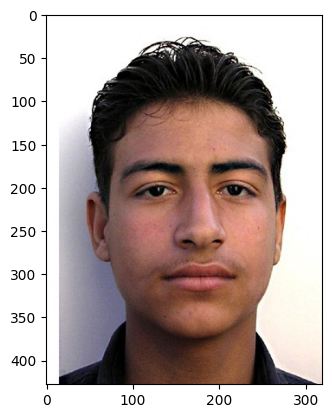

In [13]:
img = mpimg.imread('/content/data/without_mask/without_mask_1003.jpg')
imgplot = plt.imshow(img)
plt.show()

In [14]:
with_mask_path = '/content/data/with_mask/'
data = []
for img_file in with_mask_files:
  image = Image.open(os.path.join(with_mask_path, img_file))
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

without_mask_path = '/content/data/without_mask/'
for img_file in without_mask_files:
  image = Image.open(os.path.join(without_mask_path, img_file))
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [15]:
type(data)


list

In [16]:
len(data)

7553

array([[[255, 254, 230],
        [255, 253, 234],
        [255, 253, 238],
        ...,
        [253, 254, 245],
        [249, 254, 241],
        [243, 254, 238]],

       [[255, 253, 226],
        [255, 253, 229],
        [255, 252, 232],
        ...,
        [253, 255, 244],
        [249, 254, 240],
        [242, 253, 236]],

       [[254, 254, 220],
        [254, 253, 221],
        [254, 253, 221],
        ...,
        [252, 254, 242],
        [248, 253, 238],
        [242, 253, 234]],

       ...,

       [[234, 229, 173],
        [225, 223, 166],
        [212, 213, 159],
        ...,
        [245, 239, 179],
        [248, 241, 182],
        [246, 237, 181]],

       [[220, 216, 157],
        [221, 219, 160],
        [219, 220, 165],
        ...,
        [241, 237, 167],
        [250, 244, 177],
        [250, 241, 180]],

       [[226, 222, 161],
        [222, 220, 160],
        [179, 181, 124],
        ...,
        [242, 239, 160],
        [253, 249, 173],
        [251, 244, 174]]], dtype=uint8)
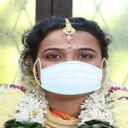

In [17]:
data[0]

In [18]:
type(data[0])

numpy.ndarray

In [19]:
data[0].shape

(128, 128, 3)

In [20]:
X = np.array(data)
Y = np.array(labels)
type(X)
type(Y)


numpy.ndarray

In [21]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [22]:
print(Y)

[1 1 1 ... 0 0 0]


In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [24]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [109, 107, 110],
        [104, 102, 105],
        [102, 100, 103]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 89,  87,  90],
        [ 94,  92,  95],
        [ 86,  84,  87]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 85,  83,  86],
        [ 85,  83,  86],
        [ 76,  74,  77]],

       ...,

       [[255, 254, 255],
        [255, 255, 254],
        [255, 255, 251],
        ...,
        [113,  67,  61],
        [114,  68,  63],
        [115,  69,  64]],

       [[255, 253, 255],
        [255, 254, 255],
        [254, 255, 254],
        ...,
        [136,  89,  84],
        [157, 108, 105],
        [159, 111, 107]],

       [[255, 253, 255],
        [255, 255, 255],
        [253, 255, 255],
        ...,
        [177, 127, 123],
        [181, 131, 128],
        [188, 137, 134]]], dtype=uint8)
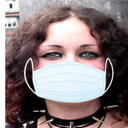

In [25]:
X_train[11]

In [26]:
X_train_scaled[11]

array([[[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [0.42745098, 0.41960784, 0.43137255],
        [0.40784314, 0.4       , 0.41176471],
        [0.4       , 0.39215686, 0.40392157]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [0.34901961, 0.34117647, 0.35294118],
        [0.36862745, 0.36078431, 0.37254902],
        [0.3372549 , 0.32941176, 0.34117647]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [0.33333333, 0.3254902 , 0.3372549 ],
        [0.33333333, 0.3254902 , 0.3372549 ],
        [0.29803922, 0.29019608, 0.30196078]],

       ...,

       [[1.        , 0.99607843, 1.        ],
        [1.        , 1.        , 0.99607843],
        [1.        , 1

In [28]:
import tensorflow as tf
from tensorflow import keras
num_of_classes = 2
model = keras.Sequential()
model.add(keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size = (2,2)))
model.add(keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size = (2,2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(64,activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(num_of_classes, activation = 'sigmoid'))
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['acc'])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,400,706 (28.23 MB)

 Trainable params: 7,400,706 (28.23 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(X_train_scaled, Y_train, validation_split = 0.1, epochs = 5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - acc: 0.7745 - loss: 0.4759 - val_acc: 0.9058 - val_loss: 0.2402
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.8968 - loss: 0.2721 - val_acc: 0.9124 - val_loss: 0.2180
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9071 - loss: 0.2514 - val_acc: 0.9157 - val_loss: 0.2347
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9218 - loss: 0.2034 - val_acc: 0.9174 - val_loss: 0.2097
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9347 - loss: 0.1713 - val_acc: 0.9256 - val_loss: 0.1650


In [30]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print("Test accuracy = ", accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9279 - loss: 0.1803
Test accuracy =  0.9278623461723328


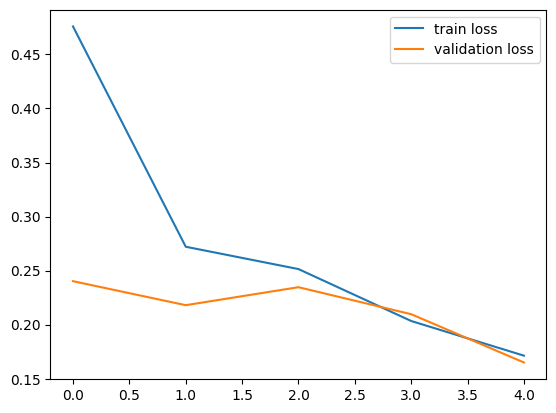

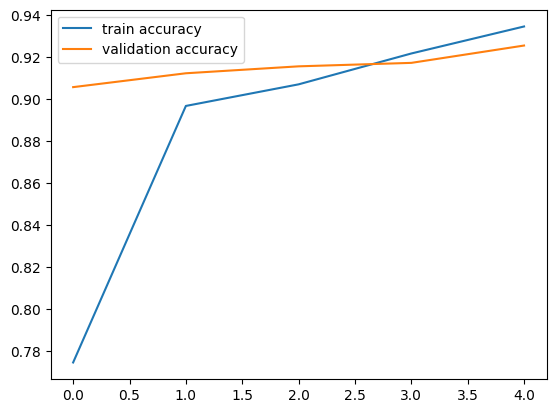

In [31]:
h = history
plt.plot(h.history['loss'], label = 'train loss')
plt.plot(h.history['val_loss'], label = 'validation loss')
plt.legend()
plt.show()
plt.plot(h.history['acc'], label = 'train accuracy')
plt.plot(h.history['val_acc'], label = 'validation accuracy')
plt.legend()
plt.show()

Path of the image to be predicted: /content/data/with_mask/with_mask_10.jpg


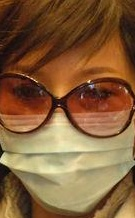

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step
[[0.2473052 0.8430666]]
1
The person in the image is wearing a mask


In [32]:
input_image_path = input("Path of the image to be predicted: ")
input_image = cv2.imread(input_image_path)
cv2_imshow(input_image)
input_image_resized = cv2.resize(input_image, (128,128))
input_image_scaled = input_image_resized/255
input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])
input_prediction = model.predict(input_image_reshaped)
print(input_prediction)
input_pred_label = np.argmax(input_prediction)
print(input_pred_label)
if input_pred_label == 1:
  print("The person in the image is wearing a mask")
else:
  print("The person in the image is not wearing a mask")